# Visualizing distributions

**Worksheet · Data 110 · Fall 2026**
Rebin Muhammad

This is the worksheet for the lecture. Do it in class, after the slides. Run each cell with **Shift+Enter**, from the top.

Under each exercise there is an empty cell. Write your solution in that cell, then run it. This file does not contain the answers.

## How to open this in Google Colab

1. Go to [colab.research.google.com](https://colab.research.google.com).
2. Choose **File → Upload notebook** and select this file.
3. Upload `titanic.csv` before you run the data cell. Click the **folder icon** on the left, then the **upload icon**, and choose the file. The name must stay `titanic.csv`. Colab forgets uploaded files when the session ends, so you upload it again next time.


## Setup

This cell loads the three packages we use. A package is a collection of functions written by someone else. The short names `plt`, `np`, and `pd` are the usual nicknames.


In [2]:
import matplotlib.pyplot as plt  # pyplot draws the plots. We call it plt.
import numpy as np               # numpy does the math. We call it np.
import pandas as pd              # pandas holds tables. We call it pd.

# rcParams is matplotlib's list of default settings.
# A change here applies to every plot after this cell.
# The spines are the four lines that make the frame.
# False hides the top line and the right line.
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

FILL = "#56B4E9"  # the blue used for a single series in the lecture


## The passenger table

One row is one passenger on the Titanic. We keep four columns.

- `age` is in years. `0.17` is about two months. The oldest age in the file is 71.
- `sex` is `female` or `male`.
- `class` is `1st`, `2nd`, or `3rd`.
- `survived` is `survived` or `died`.

`read_csv` turns the file into a table. The second line keeps those four columns. `sort_values` puts the youngest passenger first. `head()` shows the first five rows. The last line of a cell is shown under the cell.


In [3]:
titanic = pd.read_csv("https://raw.github.com/Alissa-Ouspen/data110_alissa/main/datasets/titanic.csv")
titanic = titanic[["age", "sex", "class", "survived"]]
titanic = titanic.sort_values(["age", "sex", "class"])

print(len(titanic), "passengers")
titanic.head()


756 passengers


,age,sex,class,survived
582,0.17,female,3rd,survived
572,0.33,male,3rd,died
395,0.80,male,2nd,survived
259,0.83,male,2nd,survived
452,0.83,male,3rd,survived


## 1. Histograms

A histogram chooses edges, then counts how many ages fall between each pair of edges. The height of a bar is that count, so the bars start at zero.

`hist` counts and draws in one step. If you do not give it edges, it chooses 10 bins across the ages that happen to be in the column.


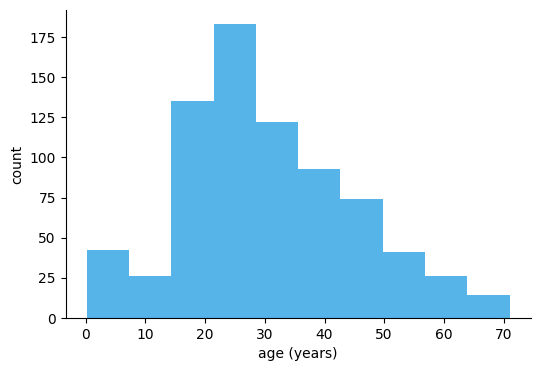

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
# fig is the whole picture. ax is the frame inside it.
# figsize is (width, height) in inches.

ax.hist(titanic["age"], color=FILL)
ax.set_xlabel("age (years)")  # the name under the x axis
ax.set_ylabel("count")        # the name beside the y axis
plt.show()                    # show() draws the picture


**Exercise.** Those 10 bins were an automatic choice. Hand `hist` the edges yourself.

`np.arange(0, 81, 5)` builds the list 0, 5, 10, …, 80. Each bin runs from one number to the next, so the bars are 5 years wide and the first bar starts at 0. A bin includes its left edge and stops before its right edge, so an age of exactly 5 is counted in 5–10. In the book this is `binwidth = 5` and `center = 2.5`: the center of the first bin is 2.5, halfway between 0 and 5.

Draw the histogram again with those edges. Keep the axis names.


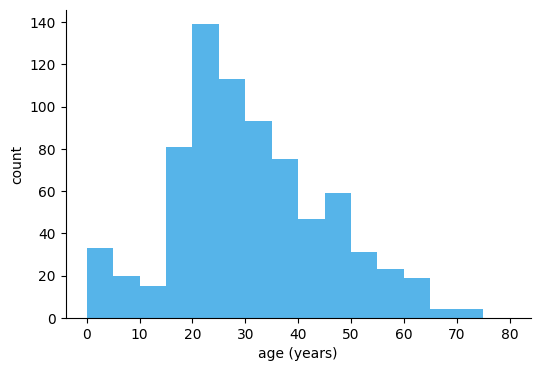

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
# fig is the whole picture. ax is the frame inside it.
# figsize is (width, height) in inches.

ax.hist(titanic["age"], bins = np.arange(0, 81, 5), color=FILL)

ax.set_xlabel("age (years)")  # the name under the x axis
ax.set_ylabel("count")        # the name beside the y axis
plt.show()                    # show() draws the picture


**Exercise.** The same width, moved over. Use edges `np.arange(2.5, 78, 5)`, so the bins run 2.5–7.5, 7.5–12.5, and so on. Passengers who sit near an edge change bars. Look at the first bar before you decide that “about 20” is a fact in the table rather than a fact about the edges.

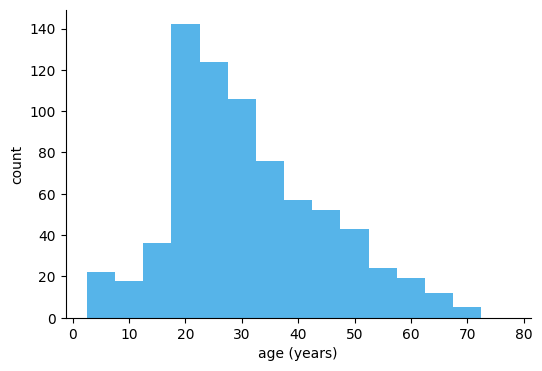

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
# fig is the whole picture. ax is the frame inside it.
# figsize is (width, height) in inches.

ax.hist(titanic["age"], bins = np.arange(2.5, 78, 5), color=FILL)

ax.set_xlabel("age (years)")  # the name under the x axis
ax.set_ylabel("count")        # the name beside the y axis
plt.show()                    # show() draws the picture


**Exercise.** Draw two histograms, one after the other.

- Width 1 year: `np.arange(0, 76, 1)`. This one keeps every small bump.
- Width 15 years: `np.arange(0, 76, 15)`. This one blends the children into the adults.

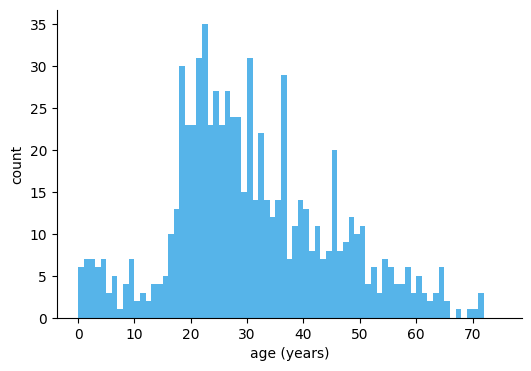

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
# fig is the whole picture. ax is the frame inside it.
# figsize is (width, height) in inches.

ax.hist(titanic["age"], bins = np.arange(0, 76, 1), color=FILL)
ax.set_xlabel("age (years)")  # the name under the x axis
ax.set_ylabel("count")        # the name beside the y axis
plt.show()                    # show() draws the picture


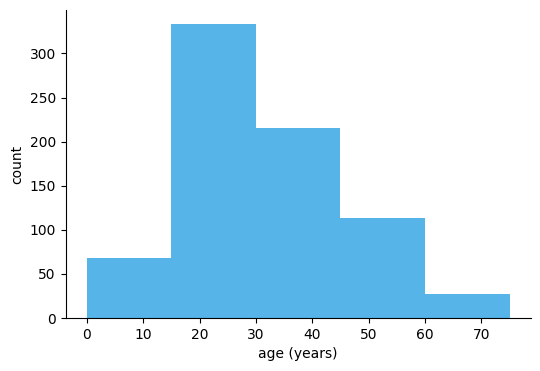

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
# fig is the whole picture. ax is the frame inside it.
# figsize is (width, height) in inches.

ax.hist(titanic["age"], bins = np.arange(0, 76, 15), color=FILL)
ax.set_xlabel("age (years)")  # the name under the x axis
ax.set_ylabel("count")        # the name beside the y axis
plt.show()                    # show() draws the picture

## 2. Density curves

A density replaces each passenger with a bump, adds the bumps, then divides by the number of people. The area under the curve is 1, so the whole curve is everyone. The height is a share of the people per year of age. A height of 0.05 means about 5 percent of the people per year, not 0.05 people.

`bw` is the width of each bump, in years. A small bandwidth follows the noise. A large one washes the peak out.

The kernel is the shape of the bump.

- `"gaussian"` is a bell. `bw` is the standard deviation of that bell.
- `"rectangular"` is flat between `age - bw` and `age + bw`.
- `"triangular"` is a tent: tallest at the passenger's age, and zero at `bw` years away.

Run the next cell once. It defines `density`. Later cells call it.


In [20]:
def density(ages, grid, bw, kernel = "gaussian"):
    ages = np.asarray(ages, dtype = float)  # the ages, as a list of numbers
    grid = np.asarray(grid, dtype = float)  # the x positions where we want a height
    # distance[i, j] is how far grid position i is from passenger j.
    distance = grid[:, None] - ages[None, :]

    if kernel == "gaussian":
        height = np.exp(-0.5 * (distance / bw) ** 2) / (bw * np.sqrt(2 * np.pi))
    elif kernel == "rectangular":
        height = np.where(np.abs(distance) <= bw, 1 / (2 * bw), 0)
    elif kernel == "triangular":
        u = np.abs(distance) / bw
        height = np.where(u < 1, (1 - u) / bw, 0)
    else:
        raise ValueError(kernel)

    # mean(axis=1) averages over passengers. The area of the result is 1.
    return height.mean(axis = 1)


`np.linspace(0, 75, 400)` makes 400 evenly spaced ages from 0 to 75. That is the grid. `fill_between` paints from zero up to the curve. `plot` draws the edge.


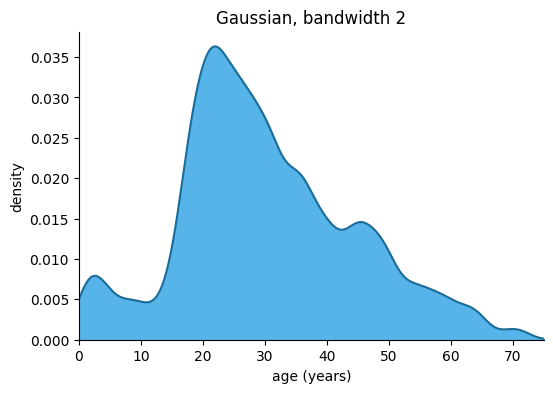

In [21]:
grid = np.linspace(0, 75, 400)        # 400 evenly spaced ages from 0 to 75
y = density(titanic["age"], grid, bw = 2) # the mean height

fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(grid, y, color = FILL)  # paints from zero up to the curve
ax.plot(grid, y, color = "#1C6C99")     # plot draws the edge
ax.set_xlim(0, 75)   # where the x axis starts and stops
ax.set_ylim(0, None)
ax.set_xlabel("age (years)")
ax.set_ylabel("density")
ax.set_title("Gaussian, bandwidth 2")
plt.show()


**Exercise.** Draw the density again with `bw=1` and `kernel="triangular"`. Use the same grid, and fill under the curve. The book asks for this pair: a narrower bump, and a tent instead of a bell.

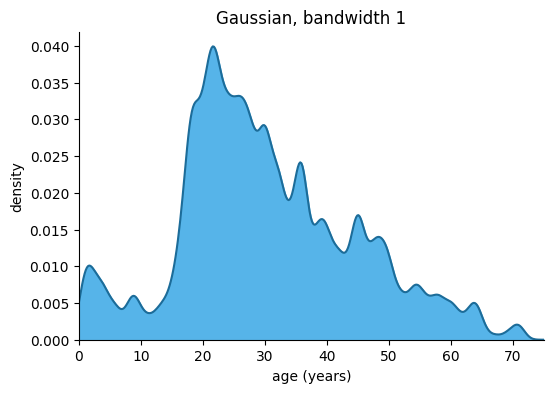

In [22]:
grid = np.linspace(0, 75, 400)        # 400 evenly spaced ages from 0 to 75
y = density(titanic["age"], grid, bw = 1) # the mean height

fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(grid, y, color = FILL)  # paints from zero up to the curve
ax.plot(grid, y, color = "#1C6C99")     # plot draws the edge
ax.set_xlim(0, 75)   # where the x axis starts and stops
ax.set_ylim(0, None)
ax.set_xlabel("age (years)")
ax.set_ylabel("density")
ax.set_title("Gaussian, bandwidth 1")
plt.show()

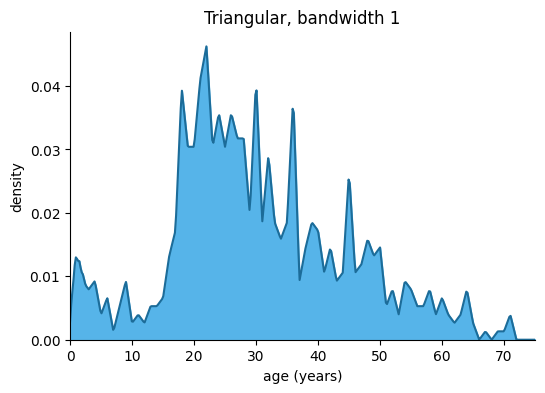

In [24]:
grid = np.linspace(0, 75, 400)        # 400 evenly spaced ages from 0 to 75
y = density(titanic["age"], grid, bw = 1, kernel = "triangular") # the mean height

fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(grid, y, color = FILL)  # paints from zero up to the curve
ax.plot(grid, y, color = "#1C6C99")     # plot draws the edge
ax.set_xlim(0, 75)   # where the x axis starts and stops
ax.set_ylim(0, None)
ax.set_xlabel("age (years)")
ax.set_ylabel("density")
ax.set_title("Triangular, bandwidth 1")
plt.show()


**Exercise.** Draw two more densities. Keep the vertical limit at `0.05` on both, so you can compare the heights.

- `bw=0.5`, Gaussian. The small bumps stay.
- `bw=5`, Gaussian. The peak near age 20 is washed out.

`set_ylim(0, 0.05)` is the line that holds the vertical scale fixed.

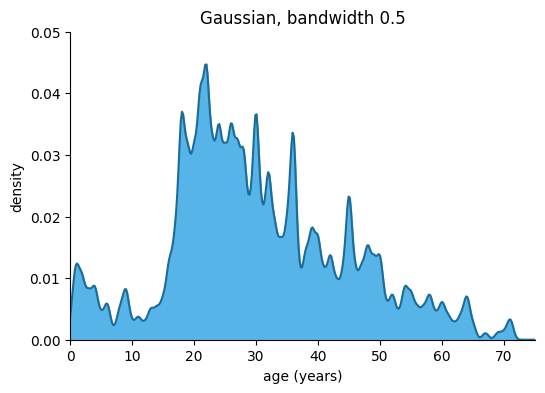

In [26]:
grid = np.linspace(0, 75, 400)        # 400 evenly spaced ages from 0 to 75
y = density(titanic["age"], grid, bw = 0.5) # the mean height

fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(grid, y, color = FILL)  # paints from zero up to the curve
ax.plot(grid, y, color = "#1C6C99")     # plot draws the edge
ax.set_xlim(0, 75)   # where the x axis starts and stops
ax.set_ylim(0, 0.05)  # changed from None to 0.05
ax.set_xlabel("age (years)")
ax.set_ylabel("density")
ax.set_title("Gaussian, bandwidth 0.5")
plt.show()


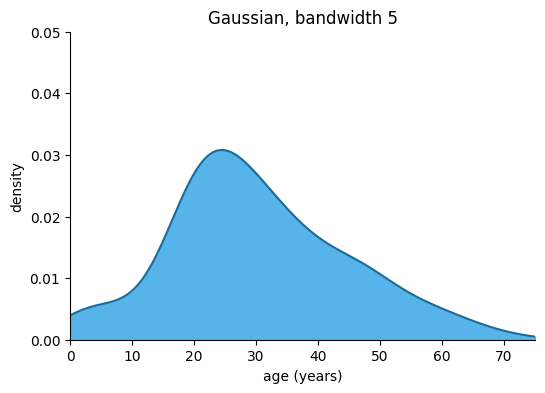

In [27]:
grid = np.linspace(0, 75, 400)        # 400 evenly spaced ages from 0 to 75
y = density(titanic["age"], grid, bw = 5) # the mean height

fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(grid, y, color = FILL)  # paints from zero up to the curve
ax.plot(grid, y, color = "#1C6C99")     # plot draws the edge
ax.set_xlim(0, 75)
ax.set_ylim(0, 0.05)
ax.set_xlabel("age (years)")
ax.set_ylabel("density")
ax.set_title("Gaussian, bandwidth 5")
plt.show()

**Exercise.** The youngest passenger is 0.17 years old. Draw the Gaussian density with `bw=2` on a grid that starts at `-10`, and set the x limit from `-10` to `80`.

Part of the curve will sit on negative ages. No passenger is that young. That part is the kernel, not the data.

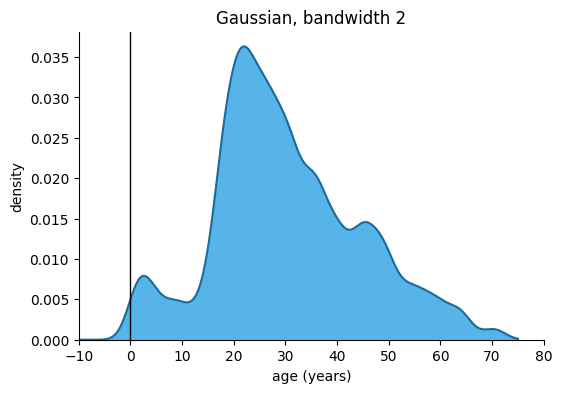

In [30]:
grid = np.linspace(-10, 75, 400)        # 400 evenly spaced ages from 0 to 75
    # density(kernel = "gaussian") is default
y = density(titanic["age"], grid, bw = 2) # the mean height

fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(grid, y, color = FILL)  # paints from zero up to the curve
ax.plot(grid, y, color = "#1C6C99")     # plot draws the edge
ax.set_xlim(-10, 80)   # where the x axis starts and stops
ax.set_ylim(0, None)
ax.set_xlabel("age (years)")
ax.set_ylabel("density")
ax.set_title("Gaussian, bandwidth 2")
plt.axvline(x = 0, color = "black", linewidth = 1)
plt.show()


## 3. Small multiples

A small multiple is the same plot, repeated for each group. The book draws these with `facet_wrap`. Here we make one axes per group with `subplots`, then loop.

`loc` picks rows. The test inside the brackets is checked once per row.

The next cell is one histogram per class. `sharey=True` forces the three panels to use the same vertical scale, so a taller bar really is more people. `zip` walks along the axes and the class names together.


## `zip()` function

The zip() function in Python is used to combine multiple iterables (like lists or tuples) element-wise. It creates an iterator that aggregates elements from each of the iterables. If the iterables have different lengths, zip() stops when the shortest iterable is exhausted.

zip(axes, classes) takes two iterables: axes (a list of subplot objects) and classes (a list of strings '1st', '2nd', '3rd') and pairs them up, respectively.

This allows the for loop to process each subplot (ax) along with its corresponding class name (name) in a single iteration.

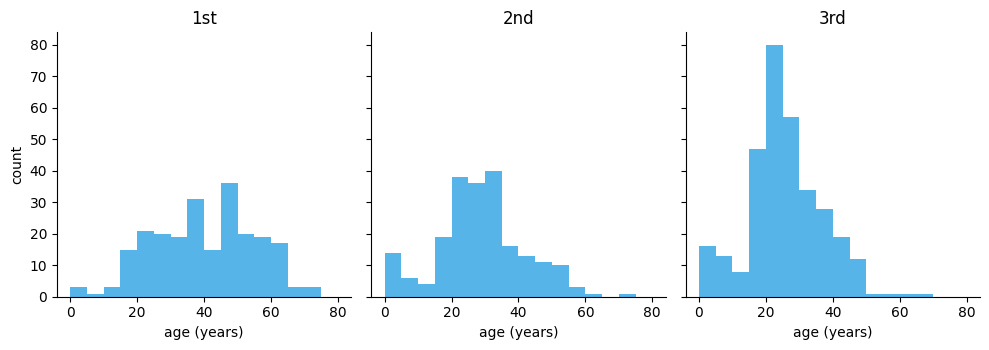

In [31]:
classes = ["1st", "2nd", "3rd"]  # the order of the panels

# subplots(1, 3) is 1 row and 3 columns.
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6), sharey = True)

# iterates through each of the 3 subplots (ax)
# & its corresponding class name (name)
for ax, name in zip(axes, classes):
        # for each class, filter the DF to select only the rows of that class
    group = titanic.loc[titanic["class"] == name]  # group is a filtered DF
    ax.hist(group["age"], bins = np.arange(0, 81, 5), color = FILL)
    ax.set_title(name)  # automate titles
    ax.set_xlabel("age (years)")

axes[0].set_ylabel("count")  # outside of loop
                    # prevents labels and titles from overlapping
plt.tight_layout()  # pulls the titles in so they are not cut off
plt.show()

# facet_wrap is another option


In [33]:
#type(group)

**Exercise.** Draw the same 5-year histogram, but one panel for passengers who died and one panel for passengers who survived. Use `sharey=True`. The panel names are `"died"` and `"survived"`, in that order.

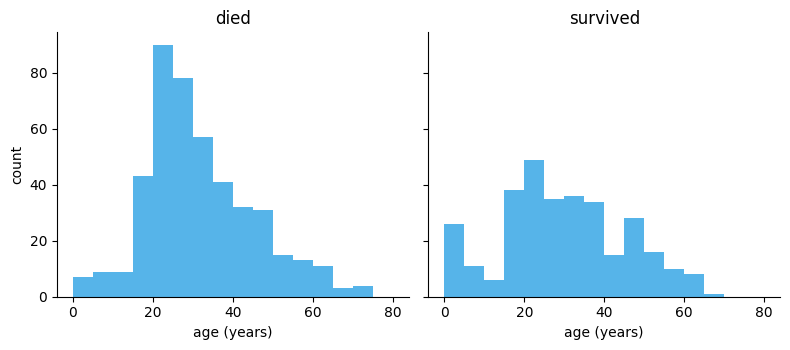

In [37]:
survival_status = ["died", "survived"]  # the order of the panels

fig, axes = plt.subplots(1, 2, figsize=(8, 3.6), sharey = True)

# iterates through each of the 2 subplots (ax)
# & its corresponding survival status
for ax, status in zip(axes, survival_status):
    survival_df = titanic.loc[titanic["survived"] == status]
    ax.hist(survival_df["age"], bins = np.arange(0, 81, 5), color = FILL)
    ax.set_title(status)  # automate titles
    ax.set_xlabel("age (years)")

axes[0].set_ylabel("count")  # outside of loop
                    # prevents labels and titles from overlapping
plt.tight_layout()  # pulls the titles in so they are not cut off
plt.show()

**Exercise.** Break the data down by survival status and class at the same time. Use 2 rows and 3 columns: rows are `"died"` and `"survived"`, columns are `"1st"`, `"2nd"`, and `"3rd"`.

`subplots(2, 3)` returns `axes` as a table. The first loop walks the rows. The second loop walks the columns of that row.

`&` means both tests must be true. The parentheses around each test are required.


### Your solution

Write your code in the next cell, then run it.


In [16]:
# Write your solution here.


**Exercise.** Draw that same 2 by 3 layout as densities, with `bw=2` and the Gaussian kernel. Use the `grid` from earlier, `np.linspace(0, 75, 400)`.

Each curve has area 1. A class with few passengers can look as tall as a class with many. The height is no longer “how many people.”


### Your solution

Write your code in the next cell, then run it.


In [17]:
# Write your solution here.


## 4. A proportion is not a count

The book writes `y = after_stat(count)` when it wants the area to follow the number of people, and `y = after_stat(density)` when it wants every panel to have area 1.

In this notebook those are two ordinary lines.

- `density(...)` has area 1.
- `density(...) * len(group)` has area equal to the number of people in the group.

The next cell is the second one, for the three classes. The title of each panel includes the count, so you can check that the larger group has the larger area.


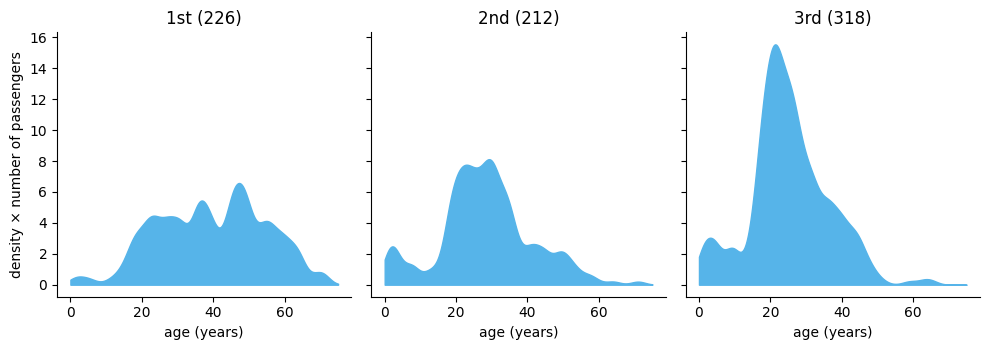

In [18]:
classes = ["1st", "2nd", "3rd"]
grid = np.linspace(0, 75, 400)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6), sharey=True)
for ax, name in zip(axes, classes):
    group = titanic.loc[titanic["class"] == name, "age"]
    y = density(group, grid, bw=2) * len(group)
    ax.fill_between(grid, y, color=FILL)
    ax.set_title(f"{name} ({len(group)})")
    ax.set_xlabel("age (years)")

axes[0].set_ylabel("density × number of passengers")
plt.tight_layout()
plt.show()


**Exercise.** Go back to the 2 by 3 histogram (survival status by class). Add `density=True` inside `hist`.

That switch divides each count by the group size, so the y axis becomes a proportion and every panel is on a comparable scale. Set the y-axis label to `"proportion"`. The shape can stay similar. The meaning of the height changes.


### Your solution

Write your code in the next cell, then run it.


In [19]:
# Write your solution here.


## What to keep

- **Histogram.** Edges plus counts. The height is how many cases fell in the bin, so the bars include zero. The width and the placement of the edges can create or hide a bump.
- **Density.** One bump per person. Add the bumps and divide by the number of people. The area is 1. The height is a share per year, so the tallest Titanic bar, 139 people in a 5-year bin, is about 139 / (756 × 5) ≈ 0.037. Bandwidth is the width of the bump. The kernel is its shape.
- **Support.** The curve can enter values that never occur, such as a negative age. That part is the kernel, not the data.
- **Small multiples.** One panel per group, with a shared scale. Area 1 makes groups look the same size. Multiply by the number of people when the count matters.

The argument follows Claus O. Wilke, *Fundamentals of Data Visualization*, Chapter 7. This worksheet is the Python version for Data 110, Fall 2026.
